# Starter Notebook — Your First Gut Microbiome Analysis

Welcome. This is your first real analysis. It uses a small teaching dataset
(`example_gut_samples.csv`) shaped exactly like real gut microbiome data: one row
per person, columns for the relative abundance (%) of major gut bacteria, plus
group / age / country.

**The most important rule in this whole notebook — the read-run-modify-explain loop:**
1. **Read** the code + my comment above it.
2. **Run** the cell (click it, press `Shift + Enter`).
3. **Modify** — do the `YOUR TURN` task. Change one thing, *predict* the result before running.
4. **Explain** — in the `EXPLAIN` markdown cell, write in your own words what the code did.

Do NOT skip steps 3 and 4. That's where coding actually sticks. If you get an
error, don't panic — copy it to me. Errors are normal and expected.

## 1. Load the tools

Every analysis starts by importing libraries. `pandas` handles tables, `matplotlib`/`seaborn` make plots. The `as pd` gives them short nicknames.

In [ ]:
%pip install -q seaborn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Tools loaded!")

Matplotlib is building the font cache; this may take a moment.


Tools loaded!


## 2. Load the data

`pd.read_csv` reads a spreadsheet-like file into a *dataframe* — think of it as a programmable Excel sheet. `.head()` shows the first 5 rows.

In [2]:
df = pd.read_csv("example_gut_samples.csv")
df.head()

,sample_id,group,age,country,Faecalibacterium,Bacteroides,Prevotella,Bifidobacterium,Escherichia,Other
0,S01,low_mood,42,Japan,6.76,26.07,6.64,1.02,1.02,58.48
1,S02,low_mood,38,USA,3.40,22.41,17.98,1.50,1.50,53.21
2,S03,low_mood,51,USA,7.88,23.73,15.14,3.60,1.27,48.38
3,S04,low_mood,30,Italy,8.35,25.79,19.52,1.64,1.83,42.86
4,S05,low_mood,54,Japan,1.12,13.26,10.58,2.43,3.28,69.33


### YOUR TURN #1
`.head()` shows the first 5 rows. **Predict:** what will `.head(10)` show? Change
the cell below to `df.head(10)`, predict the answer out loud, then run it.
Also try `df.tail()` — what do you think that does?

In [4]:
# Change this line, predict first, then run:
df.tail(10)

,sample_id,group,age,country,Faecalibacterium,Bacteroides,Prevotella,Bifidobacterium,Escherichia,Other
14,S15,control,27,USA,8.53,22.98,10.24,2.06,1.40,54.79
15,S16,control,51,Italy,12.95,25.52,14.10,2.97,0.58,43.88
16,S17,control,25,Italy,13.23,26.27,17.85,5.63,0.84,36.19
17,S18,control,46,USA,12.63,26.76,17.57,6.68,1.13,35.23
18,S19,control,49,USA,9.00,19.91,19.32,8.99,4.55,38.22
19,S20,control,51,USA,11.70,19.23,13.21,10.83,1.01,44.02
20,S21,control,29,USA,11.35,27.15,10.61,5.83,3.01,42.05
21,S22,control,51,Italy,11.66,20.85,13.36,3.02,0.92,50.19
22,S23,control,25,Italy,13.61,14.35,0.50,0.74,3.12,67.68
23,S24,control,39,USA,11.67,15.20,2.42,5.54,2.46,62.71


### EXPLAIN #1 (double-click to edit this cell)

*What does `.head()` do? What did `.head(10)` and `.tail()` do differently? Write it in your own words:*

> your answer here

## 3. Get the lay of the land

Two essential commands: `.shape` tells you (rows, columns). `.columns` lists the column names. `.describe()` gives summary statistics for every number column.

In [5]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(list(df.columns))

Rows and columns: (24, 10)

Column names:
['sample_id', 'group', 'age', 'country', 'Faecalibacterium', 'Bacteroides', 'Prevotella', 'Bifidobacterium', 'Escherichia', 'Other']


In [8]:
df.describe()

,age,Faecalibacterium,Bacteroides,Prevotella,Bifidobacterium,Escherichia,Other
count,24.000000,24.00000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,39.583333,8.46750,21.447500,12.732083,3.882917,1.895833,51.575000
std,11.181960,3.54835,5.014217,5.406988,2.561422,1.153942,9.631749
min,23.000000,1.12000,11.900000,0.500000,0.740000,0.000000,35.230000
25%,28.500000,6.23000,18.927500,10.495000,1.955000,1.017500,43.985000
50%,39.000000,8.41500,20.600000,13.285000,2.995000,1.655000,51.785000
75%,51.000000,11.66250,25.860000,17.700000,5.562500,2.597500,58.920000
max,54.000000,13.61000,30.970000,19.520000,10.830000,4.550000,69.330000


### YOUR TURN #2
`df.shape` printed two numbers. **Predict:** how many people (rows) are in this
study? How many columns? Then look at `df.describe()` above — find the *average*
(mean row) age. Is the youngest person (min) younger than you?

### EXPLAIN #2

*How many samples are in this dataset? What's one thing `.describe()` told you that surprised you?*

> your answer here

## 4. Ask a real question: does *Faecalibacterium* differ by mood group?

*Faecalibacterium* is a butyrate-producing gut bacterium that several studies
report is **lower in people with depression**. Our data has a `group` column
(`low_mood` vs `control`). Let's compare.

`.groupby("group")` splits the table by group; then we pick the
`Faecalibacterium` column and take the `.mean()`.

In [9]:
df.groupby("group")["Faecalibacterium"].mean().round(2)

group
control     11.29
low_mood     5.65
Name: Faecalibacterium, dtype: float64

### YOUR TURN #3
You just compared *Faecalibacterium* between groups. **Now try a different
bacterium.** Change `"Faecalibacterium"` to `"Bifidobacterium"` (another one
often linked to mood) and run it. Then try `"Bacteroides"`. Which ones differ
between groups, and which don't?

In [10]:
# Change the bacterium name, predict which group is higher, then run:
df.groupby("group")["Bifidobacterium"].mean().round(2)

group
control     5.26
low_mood    2.51
Name: Bifidobacterium, dtype: float64

### EXPLAIN #3

*Which bacteria differed between low_mood and control? Which didn't? What does `.groupby()` do in plain words?*

> your answer here

## 5. See it — your first plot

Numbers are hard to feel. A picture makes the difference obvious. This makes a boxplot (the spread of each group) with the individual people plotted as dots on top.

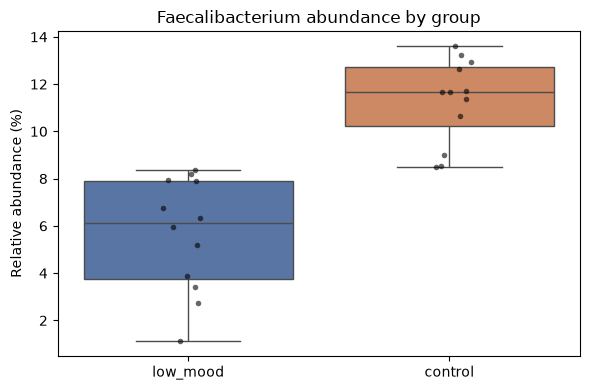

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="group", y="Faecalibacterium", hue="group",
            palette=["#4C72B0", "#DD8452"], legend=False, ax=ax)
sns.stripplot(data=df, x="group", y="Faecalibacterium",
              color="black", size=4, alpha=0.6, ax=ax)
ax.set_title("Faecalibacterium abundance by group")
ax.set_ylabel("Relative abundance (%)")
ax.set_xlabel("")
fig.tight_layout()
plt.show()

### YOUR TURN #4
Make this plot for a **different bacterium**. Copy the code cell above into the
empty cell below, change *both* `y="Faecalibacterium"` spots to another column
(e.g. `"Prevotella"`), update the title, and run. **Predict the shape first:**
will the boxes overlap a lot (no difference) or separate cleanly (a difference)?

In [ ]:
# Your plot here:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=df, x="group", y="Bifidobacterium", hue="group",
            palette=["#4C72B0", "#DD8452"], legend=False, ax=ax)
sns.stripplot(data=df, x="group", y="Bifidobacterium",
              color="black", size=4, alpha=0.6, ax=ax)
ax.set_title("Faecalibacterium abundance by group")
ax.set_ylabel("Relative abundance (%)")
ax.set_xlabel("")
fig.tight_layout()
plt.show()

### EXPLAIN #4

*What does a boxplot show you that the average number alone didn't? For your chosen bacterium — did the groups separate or overlap?*

> your answer here

## 6. Challenge (optional — stretch yourself)

Our data also has a `country` column (USA, Japan, Italy) — a nod to your
cross-cultural interest. Can you compare *Faecalibacterium* by **country**
instead of by group? (Hint: change `"group"` to `"country"` in the groupby from
Section 4.)

Real gut microbiomes genuinely differ across countries — diet, environment, and
lifestyle all shape them. This is the seed of your eventual research question.

In [14]:
# Challenge: your code here
df.groupby("country")["Faecalibacterium"].mean().round(2)

country
Italy    10.24
Japan     5.47
USA       8.85
Name: Faecalibacterium, dtype: float64

## Done! Send me your results

You just ran a complete mini-analysis: loaded data, explored it, asked a
biological question, and visualized the answer. **That's real bioinformatics.**

**Next:** tell me how it went. Paste any errors, paste your EXPLAIN answers if
you want them checked, or just say "that worked, what's next" and we'll move to
the Week-3 plan (real public data).